# Evaluation
Now it's time to make our best model (i.e Gradient Boosting) even better. Let's begin by initializing our data and model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, precision_recall_curve, auc)

# Reload and prepare data
df = pd.read_csv('../data/cumulative.csv')
df = df[df['koi_disposition'] != 'CANDIDATE']
df['label'] = (df['koi_disposition'] == 'CONFIRMED').astype(int)

features = ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad',
            'koi_teq', 'koi_impact', 'koi_steff', 'koi_slogg', 'koi_srad']

log_features = ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad', 'koi_srad']

X = df[features].copy()
for col in log_features:
    X[col] = np.log1p(X[col])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Hyperparameter Tuning
The process of improving our model begins with hyperparameter tuning. A type of tuning in which we use a different set of hyperparameters to influence the training of our model.

## What are Hyperparameters?
Hyperparameters are configuration settings defined before the model is trained, and they control the learning process and influence how the model is trained. Examples include:
- **Learning Rate:** Controls the size of the steps taken during optimization
- **Batch Rate:** Number of training examples used in one iteration
- **Number of Epochs:** How many times the entire dataset is passed through the model during training 

The hyperparameters chosen are as follows:
- **max_iter:** How many trees to build
- **max_depth:** How many "yes" or "no" questions the tree should have
- **learning_rate:** Defines how each new tree's correction counts. Lower number means the model learns carefully and slowly whereas higher number means the model learns faster but more unrefined.
- **min_sample_leaf:** The minimum number of data points that must end up in each final group (leaf) of a tree

The reason we chose these hyperparameters specifically is just related to how Gradient Boosting works.

Instead of doing hyperparameter tuning manually, scikit-learn has a function that can do it for us called `RandomizedSearchCV()`.


In [3]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', HistGradientBoostingClassifier(random_state=42))
])

param_distributions = {
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__min_samples_leaf': [10, 20]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=15,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=1
)

search.fit(X_train, y_train)

print(f"Best F1: {search.best_score_:.4f}")
print(f"Best parameters: {search.best_params_}")

Best F1: 0.8614
Best parameters: {'model__min_samples_leaf': 10, 'model__max_iter': 200, 'model__max_depth': 7, 'model__learning_rate': 0.1}


The final results tells us the hyperparameters that maximizes the model's performance:
- **min_sample_leaf:** 10
- **max_iter:** 200
- **max_depth:** 7
- **learning_rate:** 0.1 

Finding this, we can then create a confusion matrix.
# What is a Confusion Matrix?
Confusion matrix is a simple table used to measure how well a classification model is performing. It compares the predictions made by the model with the actual results and shows where the model was right or wrong. This helps you understand where the model is making mistakes so you can improve it. It breaks down the predictions into four categories:
- **True Positive (TP):** The model correctly predicted a positive outcome i.e the actual outcome was positive.
- **True Negative (TN):** The model correctly predicted a negative outcome i.e the actual outcome was negative.
- **False Positive (FP):** The model incorrectly predicted a positive outcome i.e the actual outcome was negative. It is also known as a Type I error.
- **False Negative (FN):** The model incorrectly predicted a negative outcome i.e the actual outcome was positive. It is also known as a Type II error.

Let's start by getting the best model, its predictions and its confidence in each prediction.

In [10]:
# Getting the best model, its predictions and its probabilities
best_model = search.best_estimator_
predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)[:, 1]

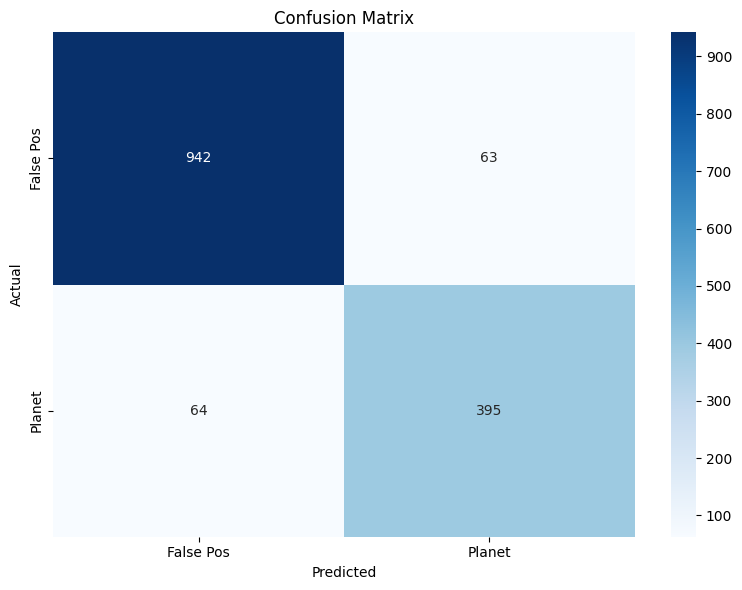

In [5]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['False Pos', 'Planet'],
            yticklabels=['False Pos', 'Planet'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Looking at this, we can map each of the categories to each box in the matrix
- Top Left: TN
- Top Right: FP
- Bottom Left: FN
- Bottom Right: TP

We can also take note that there's equal FP and FN, so there's no bias found in the model. We can also see the performance of the model across different thresholds via a ROC curve.

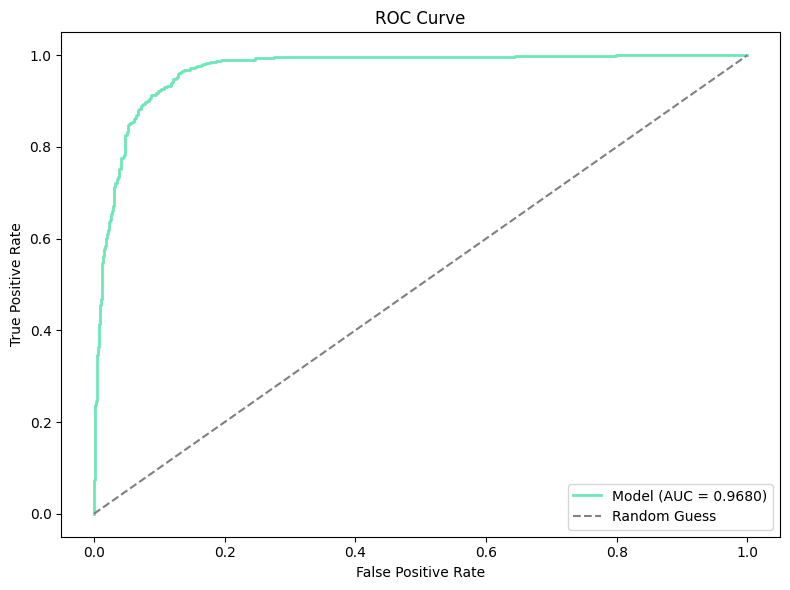

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#6ee7b7', linewidth=2, label=f'Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

We can also take a look at the Precision Recall Curve to look at how the model performs under different thresholds. It measures *recall* instead, which asks of all the real planets in the test set, how many did the model actual get right? It returns a percentage in decimal from 0 to 1.

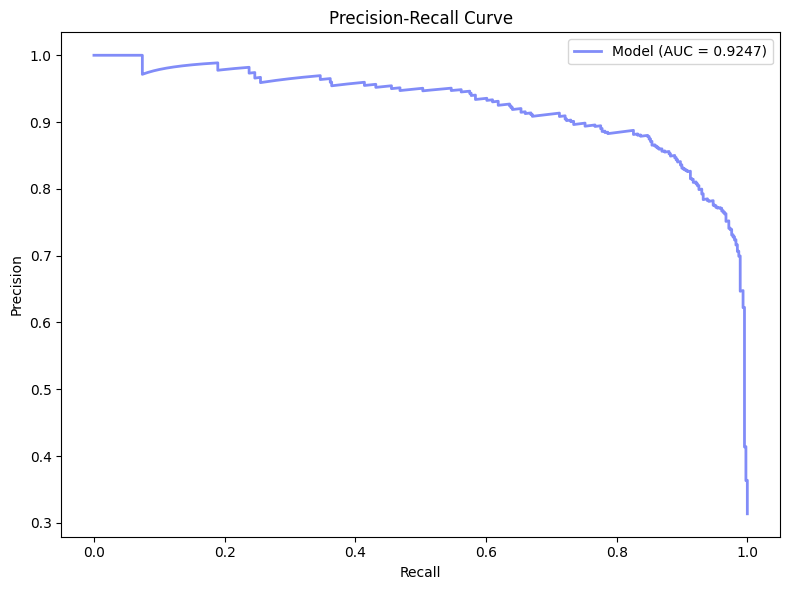

In [7]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, probabilities)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#818cf8', linewidth=2, label=f'Model (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()

Now what feature does the model actually rely on to get the correct classification? For this, we can take a look at the *feature importance* chart and by looking at which feature has the highest permutation importance, we can identify which feature the model relies on the most.

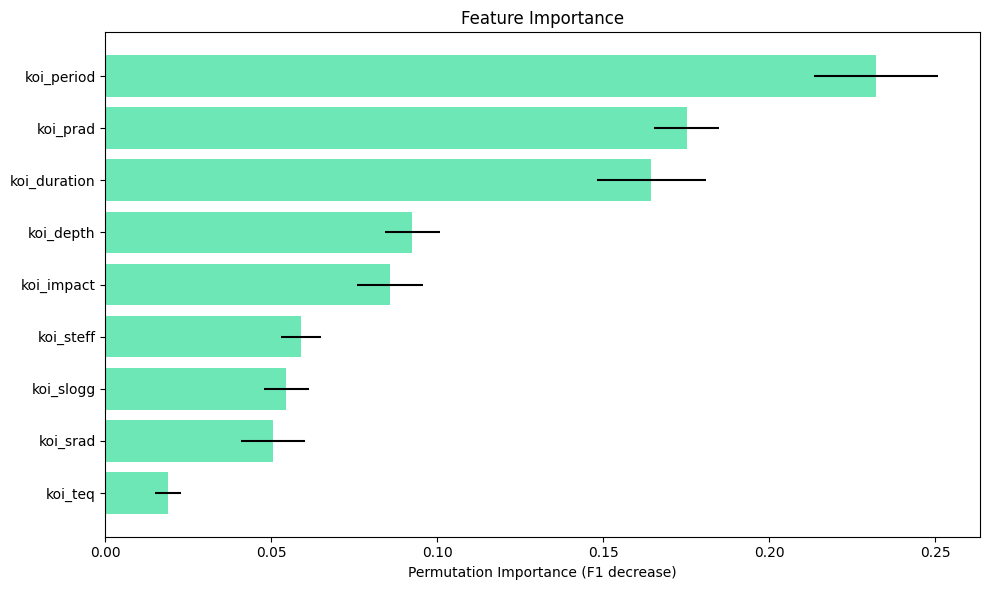

In [8]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1'
)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'],
         xerr=importance_df['std'], color='#6ee7b7')
plt.xlabel('Permutation Importance (F1 decrease)')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [9]:
print("Final Model Results:")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"\n{classification_report(y_test, predictions, target_names=['False Pos', 'Planet'])}")

Final Model Results:
Accuracy: 0.9133
ROC AUC: 0.9680

              precision    recall  f1-score   support

   False Pos       0.94      0.94      0.94      1005
      Planet       0.86      0.86      0.86       459

    accuracy                           0.91      1464
   macro avg       0.90      0.90      0.90      1464
weighted avg       0.91      0.91      0.91      1464



Our model correctly identifies 86% of real planets and when it claims something is a planet, it's right 86% of the time. It's better at spotting false positives (94%) than planets (86%), which makes sense given the class imbalance. The ROC AUC of 0.968 tells us the underlying probability rankings are very good, meaning that the model knows which signals are more planet-like even when its hard predictions occasionally miss.